# Exploratory Data Analysis (EDA) — Used Car Value Tier Prediction

This notebook follows the course EDA structure: univariate, bivariate, multivariate analysis, and a dashboard summary.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde
from matplotlib import gridspec
from matplotlib.ticker import FuncFormatter
from pandas.plotting import parallel_coordinates

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})

In [2]:
data_path = "../data/processed/validated_data.csv"

df = pd.read_csv(data_path)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

df.head()

Rows: 245630, Columns: 10


,brand,model,vehicleType,power,yearOfRegistration,kilometer,fuelType,seller,price,price_tier
0,jeep,grand,suv,163.0,2004.0,125000.0,diesel,private,9800,mid-range
1,volkswagen,golf,compact,75.0,2001.0,150000.0,gasoline,private,1500,budget
2,skoda,fabia,compact,69.0,2008.0,90000.0,diesel,private,3600,mid-range
3,bmw,3er,sedan,102.0,1995.0,150000.0,gasoline,private,650,budget
4,peugeot,2reihe,convertible,109.0,2004.0,150000.0,gasoline,private,2200,budget


## Data Cleaning and Feature Typing

Prepare numeric and categorical columns for consistent plotting and summaries.


In [3]:
df = df.copy()
df = df.replace({"": np.nan})

numeric_cols = ["power", "yearOfRegistration", "kilometer", "price"]
categorical_cols = ["brand", "model", "vehicleType", "fuelType", "seller", "price_tier"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

for col in categorical_cols:
    df[col] = df[col].astype("string").fillna("Unknown")

df_num = df[numeric_cols].dropna()
df_cat = df[categorical_cols].copy()

missing_pct = ((df.isna()) | (df == "Unknown")).mean().sort_values(ascending=False)
missing_pct.head(10)

vehicleType           0.076904
fuelType              0.073704
brand                      0.0
model                      0.0
power                      0.0
yearOfRegistration         0.0
kilometer                  0.0
seller                     0.0
price                      0.0
price_tier                 0.0
dtype: Float64

## Univariate Analysis

Distribution of individual features, including the target `price_tier`.


In [4]:
palette = {
    "budget": "#4C78A8",
    "mid-range": "#F58518",
    "luxury": "#E45756",
    "Unknown": "#72B7B2",
}

TEXT_MID = '#4A5068'  # labels

def format_thousands(x, pos):
    if x >= 1000:
        return f"{x/1000:.0f}k"
    return f"{int(x)}"

def style_axis(ax, title, xlabel="", ylabel=""):
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3, linestyle="--")

def top_n_plus_other(counts, n=10):
    top = counts.head(n).copy()
    other = counts.iloc[n:].sum()
    if other > 0:
        top.loc["Other"] = other
    return top

def plot_pie_from_counts(counts, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    ax.pie(
        counts.values,
        labels=counts.index,
        autopct="%1.1f%%",
        startangle=90,
        textprops={"fontsize": 9},
    )
    ax.set_title(title)
    plt.tight_layout()

def plot_bar_counts(counts, title, xlabel="", ylabel="Count", ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    counts.plot(kind="bar", ax=ax, color="#4C78A8", edgecolor="white")
    style_axis(ax, title, xlabel=xlabel, ylabel=ylabel)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

def plot_numeric_triple(series, label, bins=40, color="#4C78A8"):
    data = series.dropna()
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].hist(data, bins=bins, color=color, edgecolor="white")
    style_axis(axes[0], f"{label} Distribution (Histogram)", ylabel="Count")

    sns.kdeplot(data, ax=axes[1], fill=True, color=color, alpha=0.4)
    style_axis(axes[1], f"{label} Distribution (KDE)", ylabel="Density")

    axes[2].boxplot(
        data, vert=False, patch_artist=True, boxprops=dict(facecolor=color, alpha=0.5)
    )
    style_axis(axes[2], f"{label} Distribution (Box Plot)")
    plt.tight_layout()


In [5]:
ACCENT_BLUE = '#3B6FD4'  # primary accent — orders, neutral info
ACCENT_GREEN = '#2BA08B'  # positive / high ratings
ACCENT_ORANGE = '#E8922A'  # order value / weekends
ACCENT_RED = '#C94B5E'  # negative / low ratings / delivery time
CARD_BG = '#FFFFFF'  # white card background
CANVAS_BG = '#F4F6FA'  # light grey figure background
BORDER_CLR = '#D8DCE8'  # card border colour
TEXT_DARK = '#1A1D2E'  # headings
TEXT_MID = '#4A5068'  # labels
TEXT_MUTED = '#8A90A8'  # sub-labels, axis ticks
GRID_CLR = '#EAECF4'  # chart grid lines


def insight_box(ax, text, facecolor, edgecolor, y=-0.24, fontsize=10):
    """
    Draws a rounded text box below the given axis to display an insight.

    Parameters
    ----------
    ax         : Axes  – the subplot to attach the text to
    text       : str   – insight text to display
    facecolor  : str   – background color of the box
    edgecolor  : str   – border color of the box
    y          : float – vertical position in axes coords (default -0.24, below the axis)
    fontsize   : int   – font size of the insight text (default 10)

    Returns    : None  – draws directly onto ax
    """
    ax.text(
        # position: just left of center, below the axes bottom edge
        0.01,  # x: 1% from left edge in axes coords
        y,  # y: below the axis (negative = outside the axes boundary)
        text,  # insight string to display inside the box
        transform=ax.transAxes,  # axes coords so it stays fixed relative to the chart
        fontsize=fontsize,  # font size passed in by caller
        color=TEXT_MID,  # medium grey text — readable but not dominant
        bbox=dict(  # bbox: draws a box around the text
            # rounded corners with 0.5 units of internal padding
            boxstyle='round,pad=0.5',
            facecolor=facecolor,  # background color for the insight box
            edgecolor=edgecolor,  # border color matching the chart accent
            lw=0.8,  # border line width
        ),
    )
    
def kpi_card(ax, value, label, sub, accent, delta=None, delta_up=True):
    """
    Renders a KPI metric card on *ax*.

    Parameters
    ----------
    ax        : Axes   – subplot to draw on
    value     : str    – large headline number (e.g. "4.09")
    label     : str    – short descriptor under the number
    sub       : str    – small italic sub-text
    accent    : str    – hex colour used for the top bar and headline
    delta     : str    – optional trend line (e.g. "↑ 10× growth")
    delta_up  : bool   – True → green delta text; False → red

    Returns   : None   – draws directly onto ax, no return value
    """
    ax.set_facecolor(CARD_BG)  # white card background
    ax.set_xticks([])  # remove x-axis tick marks — cards have no data axis
    ax.set_yticks([])  # remove y-axis tick marks

    # ax.spines: dict of the 4 border lines (top/bottom/left/right)
    for sp in ax.spines.values():
        sp.set_edgecolor(BORDER_CLR)  # set border colour to light grey
        sp.set_linewidth(1)  # thin border line

    # Headline value — large bold number in accent color
    ax.text(
        # (x, y) in axes coordinates: 0.0=left/bottom, 1.0=right/top — centered horizontally, upper third
        0.5,  # x: centered horizontally
        0.66,  # y: upper third of the card
        value,  # the formatted string e.g. "96,096" or "R$137.75"
        # transAxes: coordinates are fractions of the axes (0–1), not data units
        transform=ax.transAxes,
        ha='center',  # horizontal alignment: center the text on x=0.5
        va='center',  # vertical alignment: center the text on y=0.66
        fontsize=24,  # large font to make the KPI number stand out
        fontweight='bold',  # bold weight for emphasis
        color=accent,  # use the passed accent color (blue/green/orange/red)
    )
    # Label — medium text describing the metric
    ax.text(
        0.5,  # x: centered horizontally
        0.45,  # y: slightly below the headline value
        label,  # e.g. "Total Orders"
        transform=ax.transAxes,  # axes fraction coordinates
        ha='center',  # center horizontally
        va='center',  # center vertically on y
        fontsize=14,  # medium font — secondary to the headline
        color=TEXT_MID,  # medium grey — less prominent than the headline
    )
    # Sub-label — small italic context text
    ax.text(
        0.5,  # x: centered horizontally
        0.28,  # y: near the bottom of the card
        sub,  # e.g. "Unique order IDs"
        transform=ax.transAxes,  # axes fraction coordinates
        ha='center',  # center horizontally
        va='center',  # center vertically on y
        fontsize=11,  # small font — least prominent text
        color=TEXT_MUTED,  # light grey — least prominent text on the card
        style='italic',  # italic to visually distinguish from the label
    )
    # Delta badge — optional trend indicator at the very bottom
    if delta:  # only draw if a delta string was passed
        ax.text(
            0.5,  # x: centered horizontally
            0.15,  # y: bottom of the card
            delta,  # e.g. "↑ 10× growth over dataset period"
            transform=ax.transAxes,  # axes fraction coordinates
            ha='center',  # center horizontally
            va='center',  # center vertically on y
            fontsize=10,  # small font for the delta badge
            color=(
                # green for positive trends, red for negative
                ACCENT_GREEN
                if delta_up
                else ACCENT_RED
            ),
            fontweight='bold',  # bold to make the trend indicator stand out
        )
    # Coloured top accent strip — a filled rectangle across the top of the card
    ax.add_patch(
        plt.Rectangle(
            # (x, y) bottom-left corner of the rectangle in axes coords — starts at 90% height
            (0, 0.90),
            1,  # width: full width of the card (100% in axes coords)
            0.10,  # height: 10% of the card height
            # use axes coords so it stays relative to the card size
            transform=ax.transAxes,
            color=accent,  # fill with the accent color (matches the headline number)
            # allow the strip to draw slightly outside the axes boundary if needed
            clip_on=False,
        )
    )


- Majority of the listed used cars are listed for low prices
- Budget cars have a high tendency of being sold in contrast to luxury cars



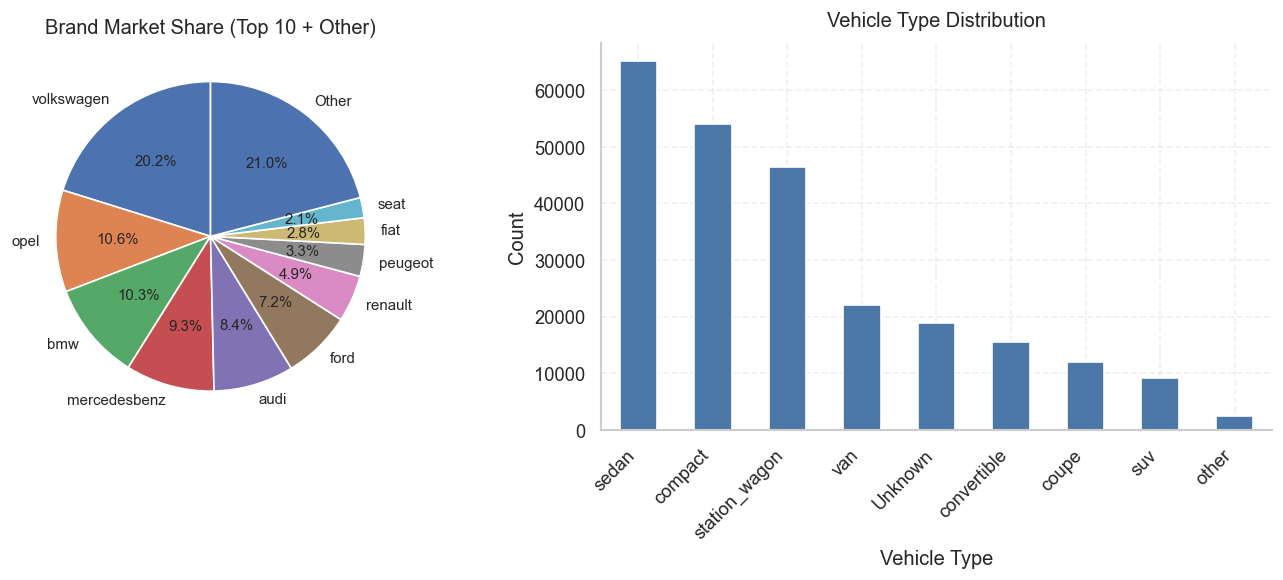

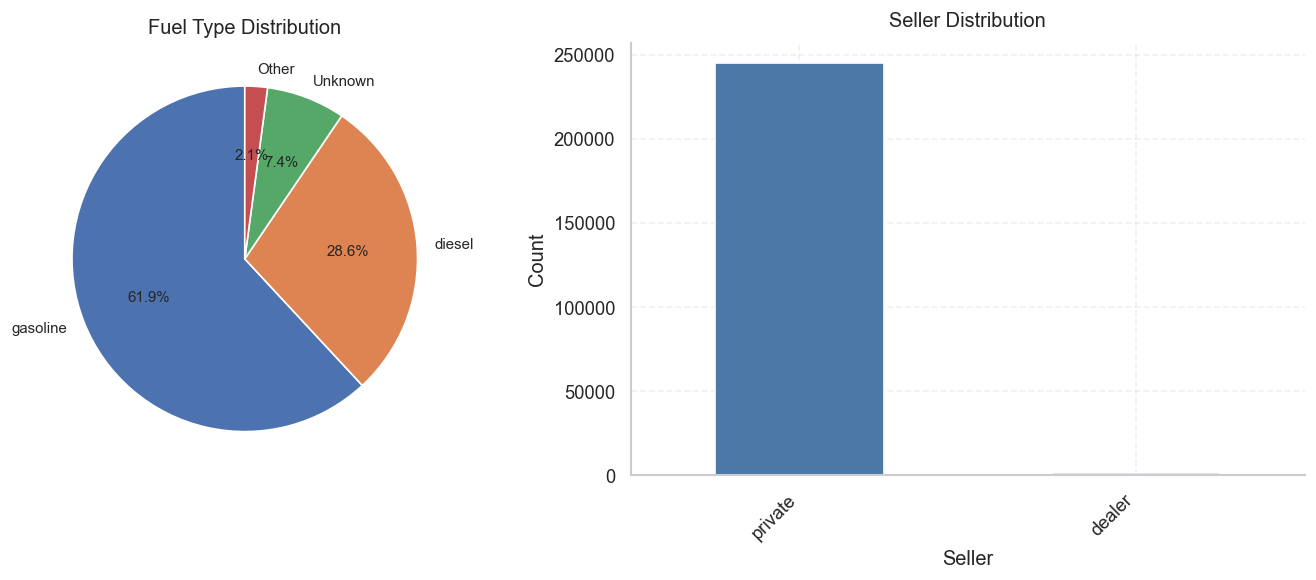

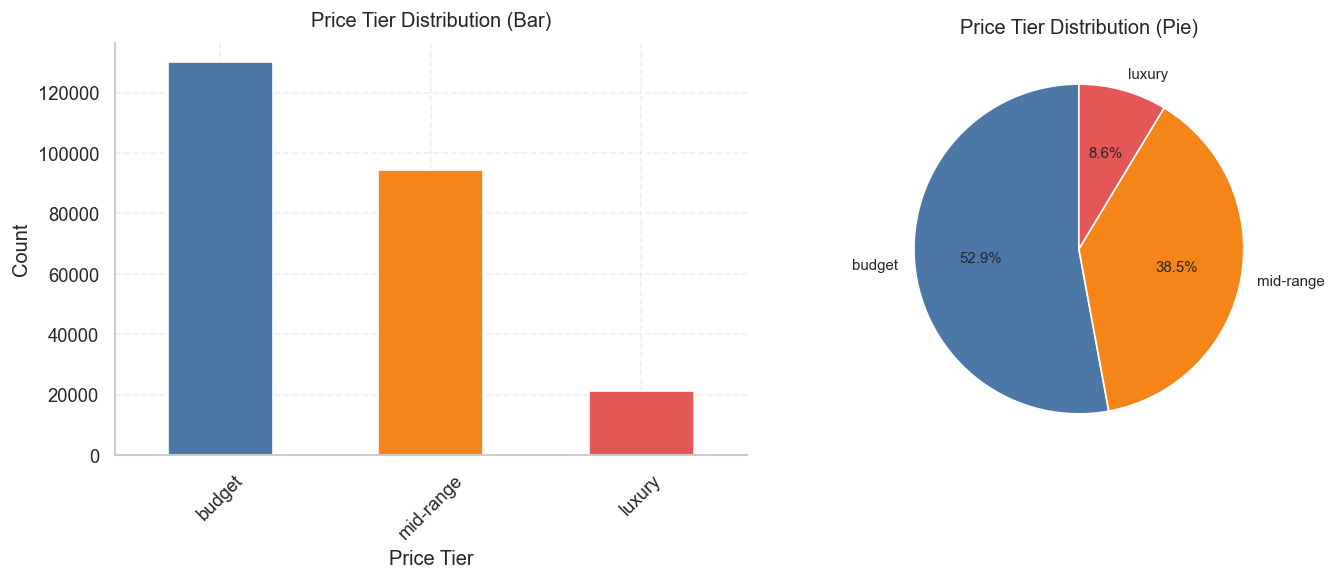

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

brand_counts = df["brand"].value_counts()
plot_pie_from_counts(top_n_plus_other(brand_counts, n=10), "Brand Market Share (Top 10 + Other)", ax=axes[0])

vehicle_counts = df["vehicleType"].value_counts()
plot_bar_counts(vehicle_counts, "Vehicle Type Distribution", xlabel="Vehicle Type", ax=axes[1])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fuel_counts = df["fuelType"].value_counts()
plot_pie_from_counts(top_n_plus_other(fuel_counts, n=3), "Fuel Type Distribution", ax=axes[0])

seller_counts = df["seller"].value_counts()
plot_bar_counts(seller_counts, "Seller Distribution", xlabel="Seller", ax=axes[1])

price_tier_counts = df["price_tier"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
price_tier_counts.plot(
    kind="bar",
    ax=axes[0],
    color=[palette.get(k, "#4C78A8") for k in price_tier_counts.index],
    edgecolor="white",
)
style_axis(axes[0], "Price Tier Distribution (Bar)", xlabel="Price Tier", ylabel="Count")
axes[0].tick_params(axis="x", rotation=45)

axes[1].pie(
    price_tier_counts.values,
    labels=price_tier_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=[palette.get(k, "#4C78A8") for k in price_tier_counts.index], 
    textprops={"fontsize": 9},
)
axes[1].set_title("Price Tier Distribution (Pie)")
plt.tight_layout()

print("""
- Majority of the listed used cars are listed for low prices
- Budget cars have a high tendency of being sold in contrast to luxury cars
""")

The price shows right skewness and that is because:
      - The majority of cars are being listed for low prices
      - Luxury cars have high prices that pull the mean to the right
      


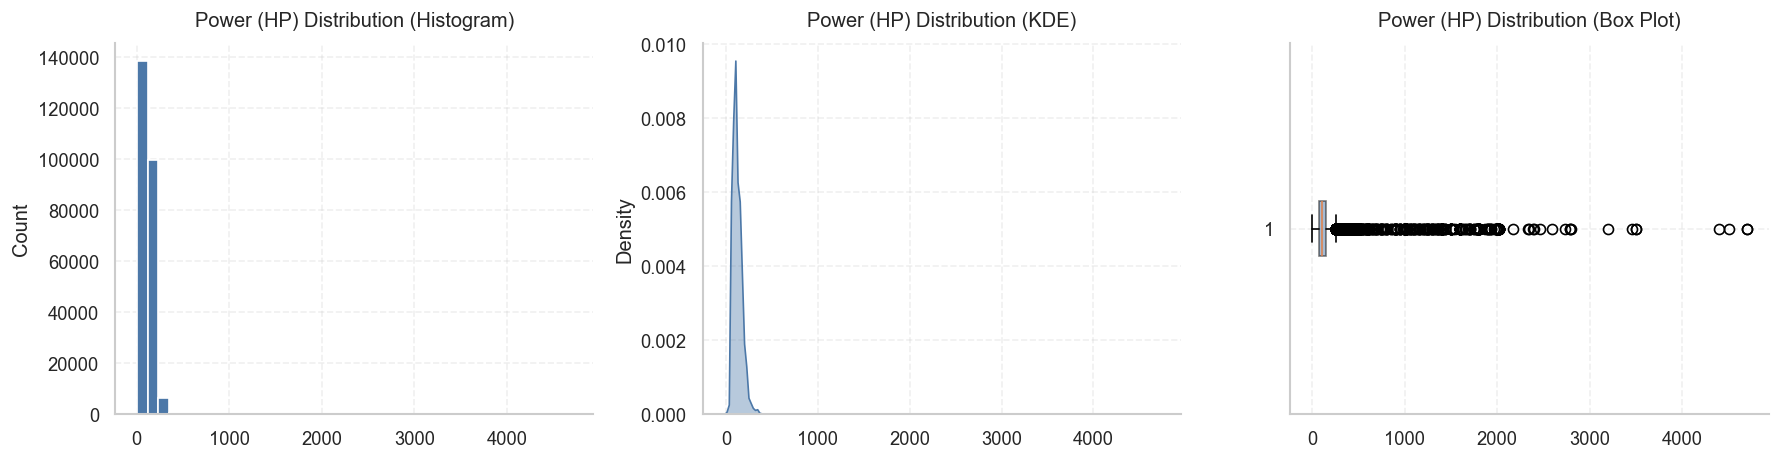

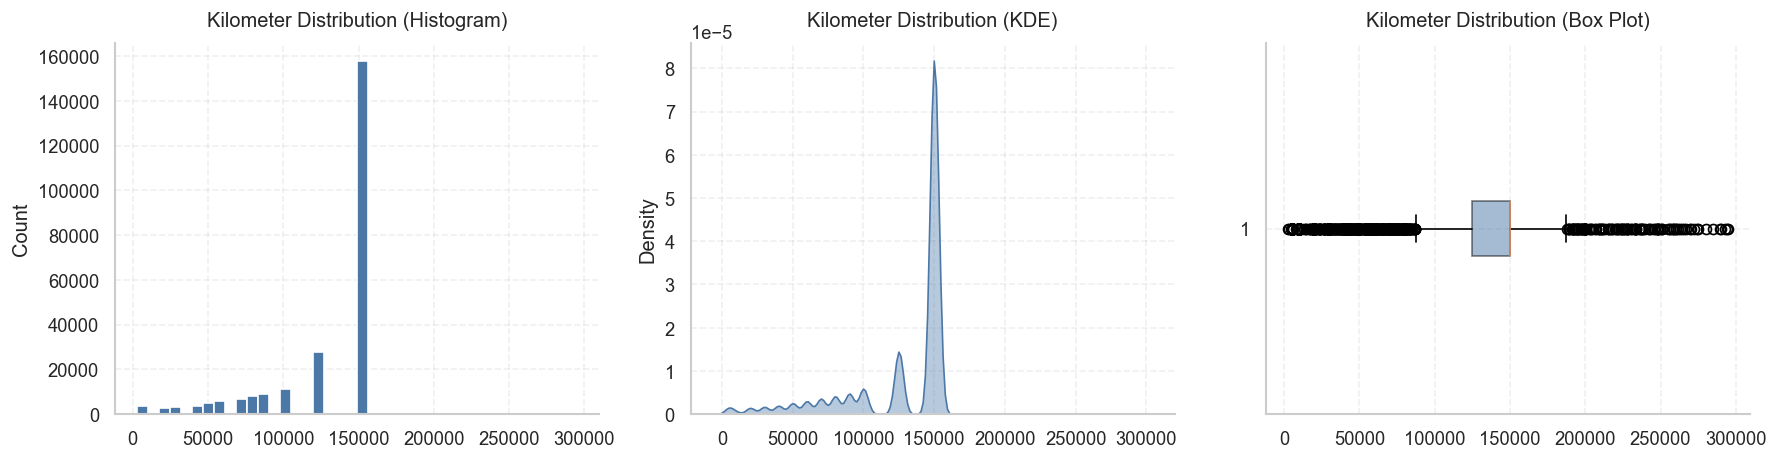

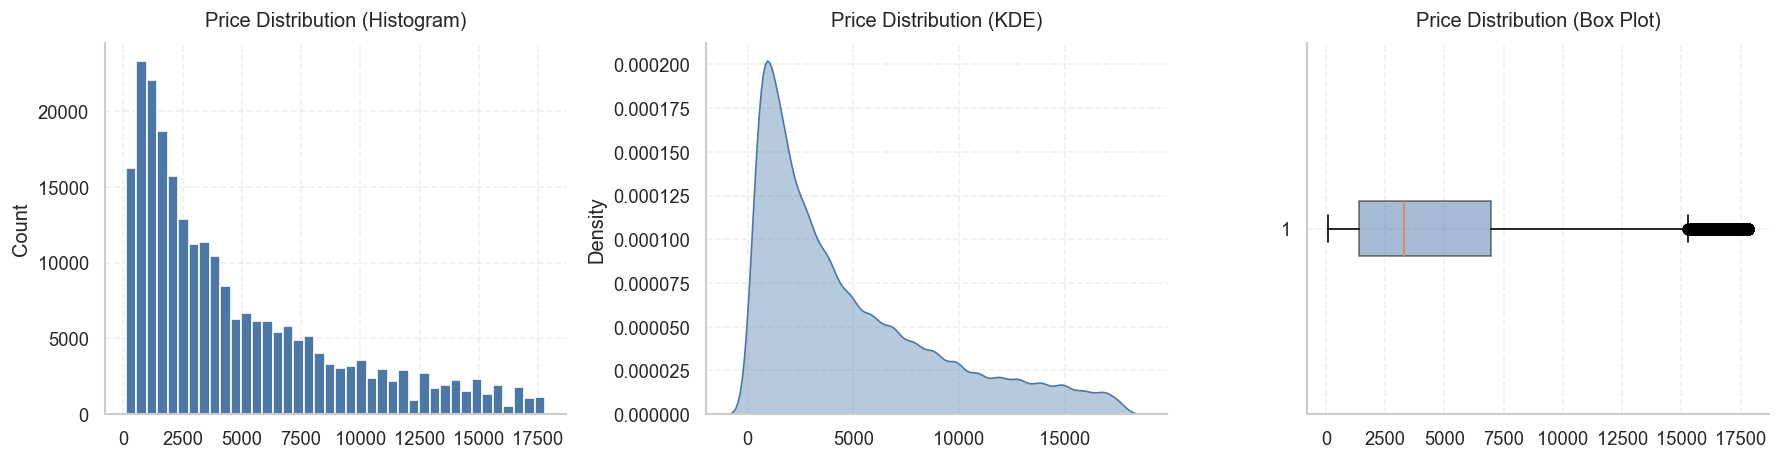

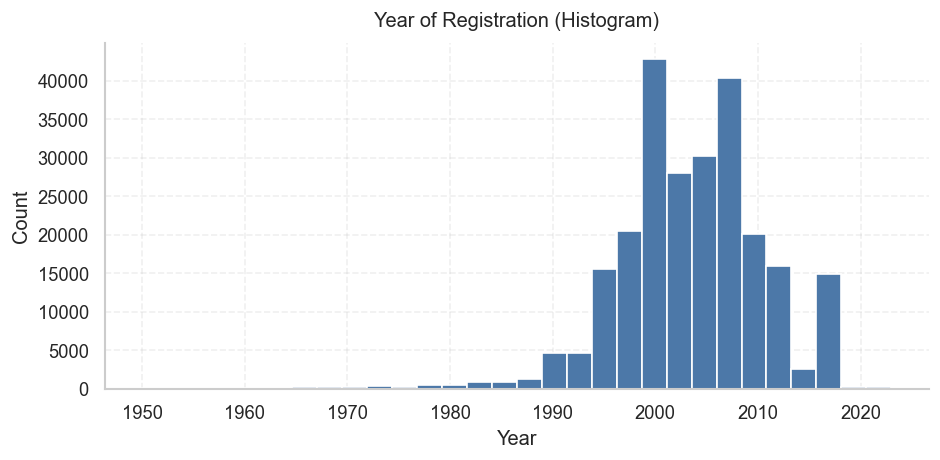

In [7]:
plot_numeric_triple(df["power"], "Power (HP)", bins=40)
plot_numeric_triple(df["kilometer"], "Kilometer", bins=40)
plot_numeric_triple(df["price"], "Price", bins=40)

print("""The price shows right skewness and that is because:
      - The majority of cars are being listed for low prices
      - Luxury cars have high prices that pull the mean to the right
      """)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["yearOfRegistration"].dropna(), bins=30, color="#4C78A8", edgecolor="white")
style_axis(ax, "Year of Registration (Histogram)", xlabel="Year", ylabel="Count")
plt.tight_layout()

## Bivariate Analysis

Explore relationships between two variables and how the target behaves across categories.


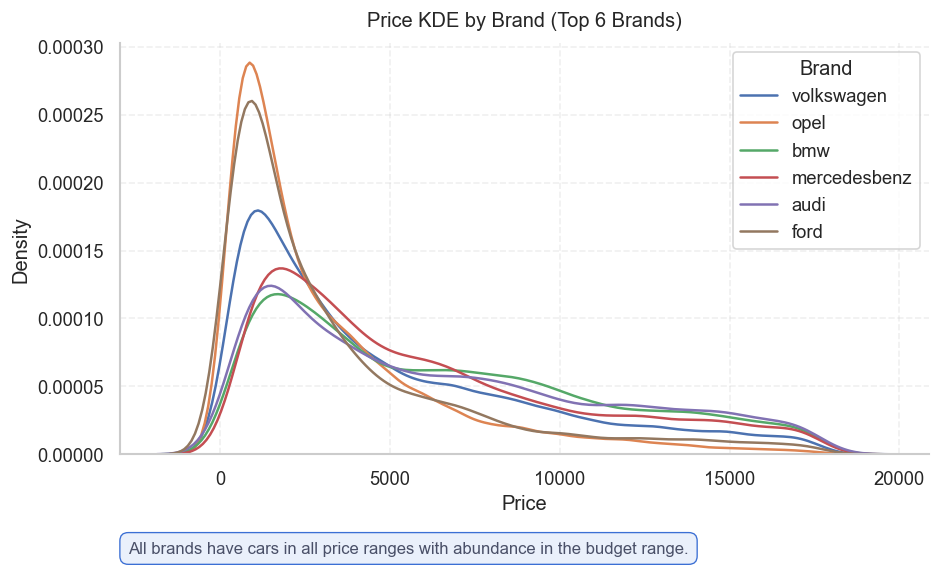

In [8]:
brand_counts = df["brand"].value_counts()
top_brands = brand_counts.head(6).index

fig, ax = plt.subplots(figsize=(8, 5))
for brand in top_brands:
    sns.kdeplot(df.loc[df["brand"] == brand, "price"].dropna(), ax=ax, label=brand)

style_axis(ax, "Price KDE by Brand (Top 6 Brands)", xlabel="Price", ylabel="Density")
ax.legend(title="Brand")
insight_box(
    ax,
    "All brands have cars in all price ranges with abundance in the budget range.",
    "#EAF0FB",
    ACCENT_BLUE,
)
plt.tight_layout()

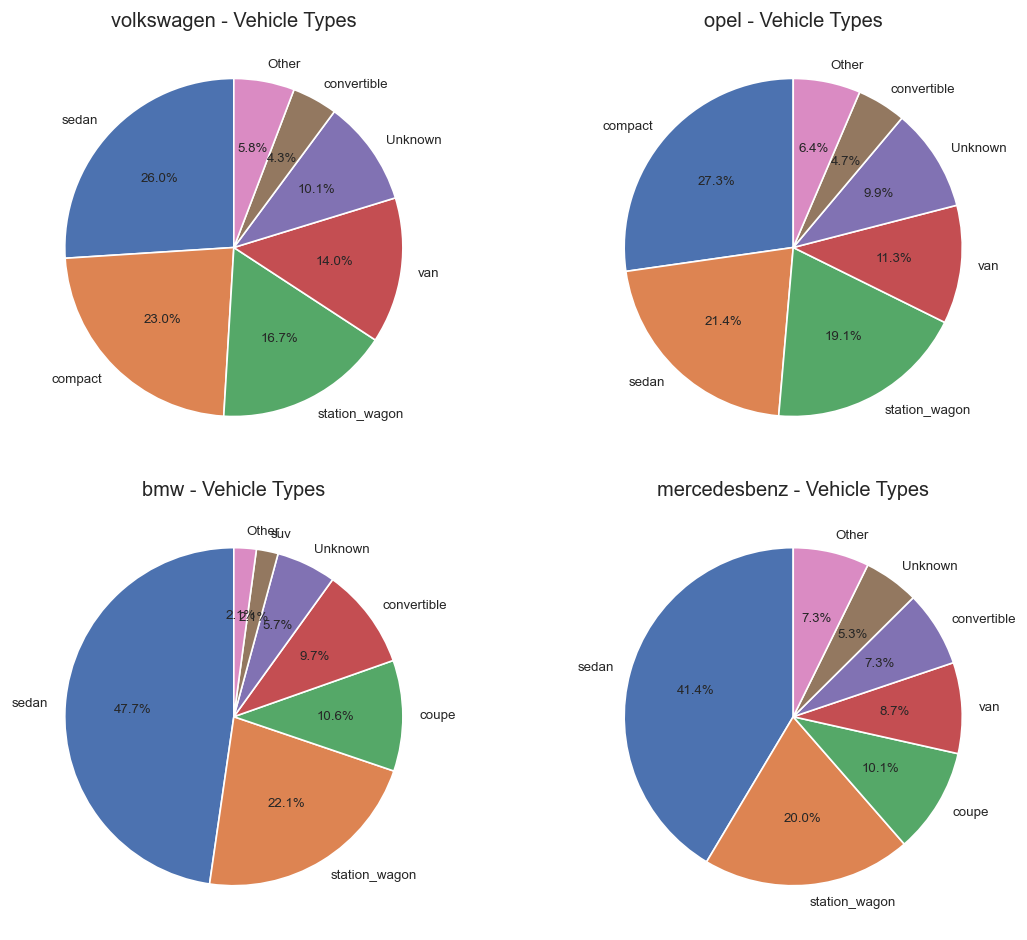

In [9]:
brand_counts = df["brand"].value_counts()
top_brands_pie = brand_counts.head(4).index

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, brand in zip(axes.flat, top_brands_pie):
    counts = df.loc[df["brand"] == brand, "vehicleType"].value_counts()
    counts = top_n_plus_other(counts, n=6)
    ax.pie(
        counts.values,
        labels=counts.index,
        autopct="%1.1f%%",
        startangle=90,
        textprops={"fontsize": 8},
    )
    ax.set_title(f"{brand} - Vehicle Types")

plt.tight_layout()

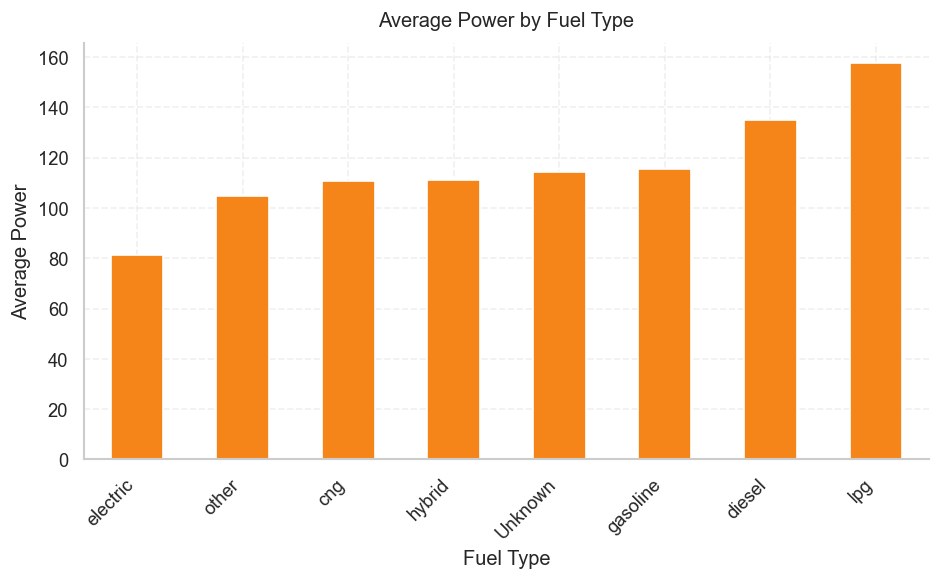

In [10]:
power_by_fuel = df.groupby("fuelType")["power"].mean().sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
power_by_fuel.plot(kind="bar", ax=ax, color="#F58518", edgecolor="white")
style_axis(ax, "Average Power by Fuel Type", xlabel="Fuel Type", ylabel="Average Power")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

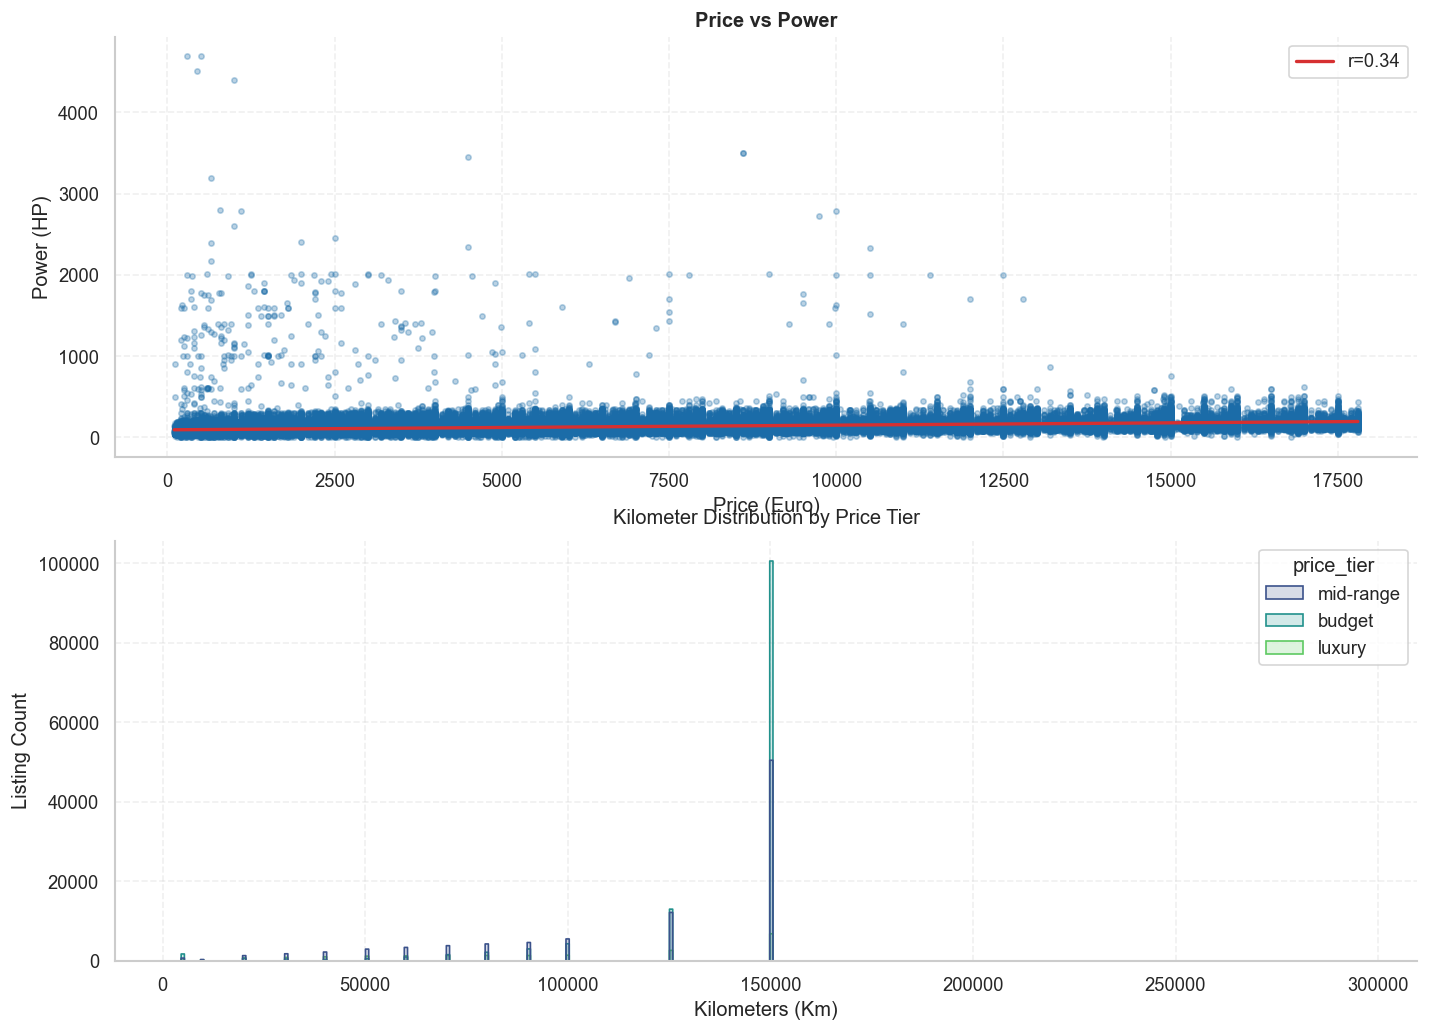

In [11]:
# ─── 2. BIVARIATE: Price vs Freight + Review by Category ──────────────────
# WHY: Scatter reveals correlation between order value and shipping cost.
#      Box plots compare distributions across groups.

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ─── Plot 2a: Scatter + Regression Line (Price vs Freight) ────────────────
# Sample 3000 rows to avoid overplotting (100k points would be a solid blob)
sample = df[['price', 'power']].dropna()
# random_state=42 makes sampling reproducible (same 3000 rows every run)

axes[0].scatter(
    sample['price'],  # X-axis: order price
    sample['power'],  # Y-axis: shipping cost
    alpha=0.3,  # Low opacity → overlapping points show density
    color='#1B6CA8',
    s=10,  # s = marker size in points² (small → less clutter)
)

# Compute regression: returns slope m, intercept b, correlation r, p-value, std_err
m, b, r, p, _ = stats.linregress(sample['price'], sample['power'])

# Draw the regression line: y = m*x + b
x_line = np.linspace(sample['price'].min(), sample['price'].max(), 100)
axes[0].plot(
    x_line,
    m * x_line + b,
    color='#D63031',
    lw=2,  # Red line, linewidth=2
    label=f'r={r:.2f}',
)  # Show r value (correlation) in legend

axes[0].legend()  # Display the label we set above
axes[0].set_xlabel('Price (Euro)')
axes[0].set_ylabel('Power (HP)')
axes[0].set_title('Price vs Power', fontsize=12, fontweight='bold')

sns.histplot(
    data=df,
    x='kilometer',
    hue='price_tier',
    element="step",       # 'step' creates a clean outline, better for comparing tiers
    palette='viridis',    # High-contrast palette for stakeholders
    ax=axes[1],
    alpha=0.2,            # Transparency helps see overlaps in mileage between tiers
)

# Apply consistent styling based on Beautifull-Dashboard.py
style_axis(
    ax=axes[1], 
    title='Kilometer Distribution by Price Tier', 
    ylabel='Listing Count', 
    xlabel='Kilometers (Km)'
)


plt.show()

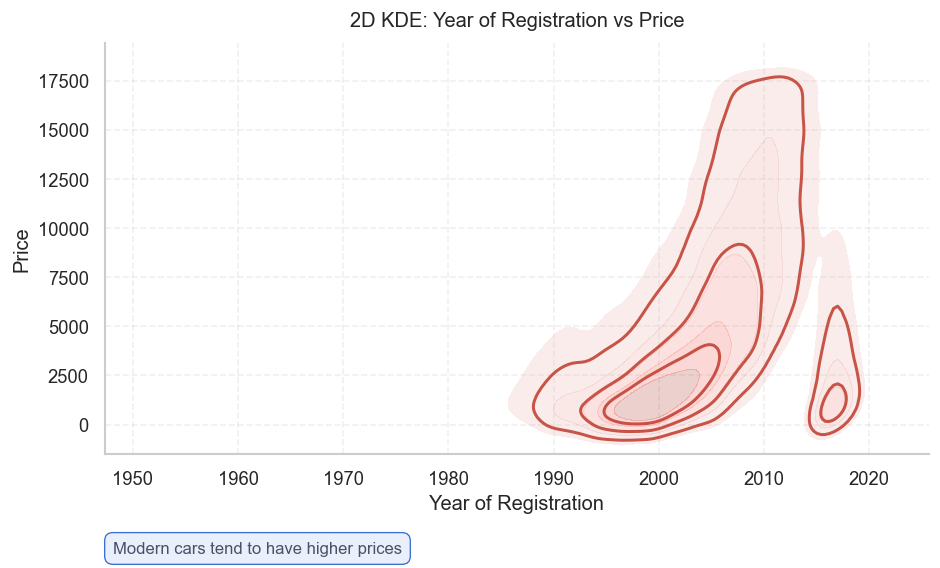

In [12]:
x = df["yearOfRegistration"]
y = df["price"]
mask = x.notna() & y.notna()
x = x[mask].astype(float)
y = y[mask].astype(float)

kde_df = pd.DataFrame({
    "yearOfRegistration": x.values,
    "price": y.values,
})

fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(
    data=kde_df,
    x="yearOfRegistration", y="price", ax=ax, fill=True,
    alpha=0.25, color="#C0392B", levels=6, thresh=0.05,
)
sns.kdeplot(
    data=kde_df, x="yearOfRegistration", y="price", ax=ax, fill=False,
    alpha=0.85, color="#C0392B", levels=4, thresh=0.10, linewidths=1.8,
)
style_axis(
    ax,
    "2D KDE: Year of Registration vs Price",
    xlabel="Year of Registration",
    ylabel="Price",
)
insight_box(
    ax,
    "Modern cars tend to have higher prices",
    "#EAF0FB",
    ACCENT_BLUE,
)
plt.tight_layout(); plt.show()

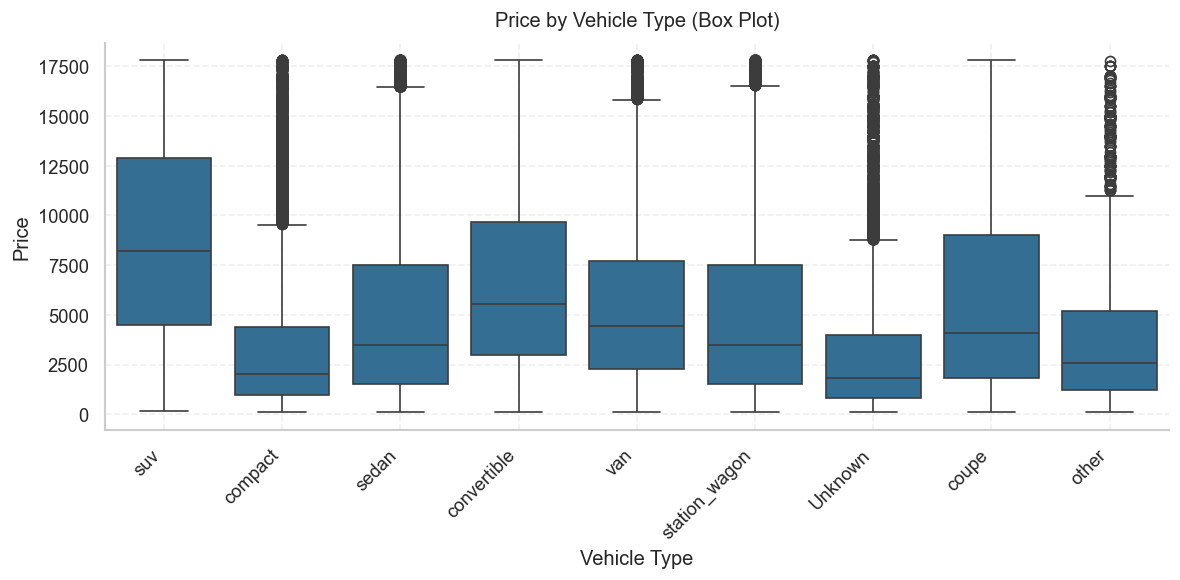

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x="vehicleType", y="price", ax=ax, color='#2471A3')
style_axis(ax, "Price by Vehicle Type (Box Plot)", xlabel="Vehicle Type", ylabel="Price")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

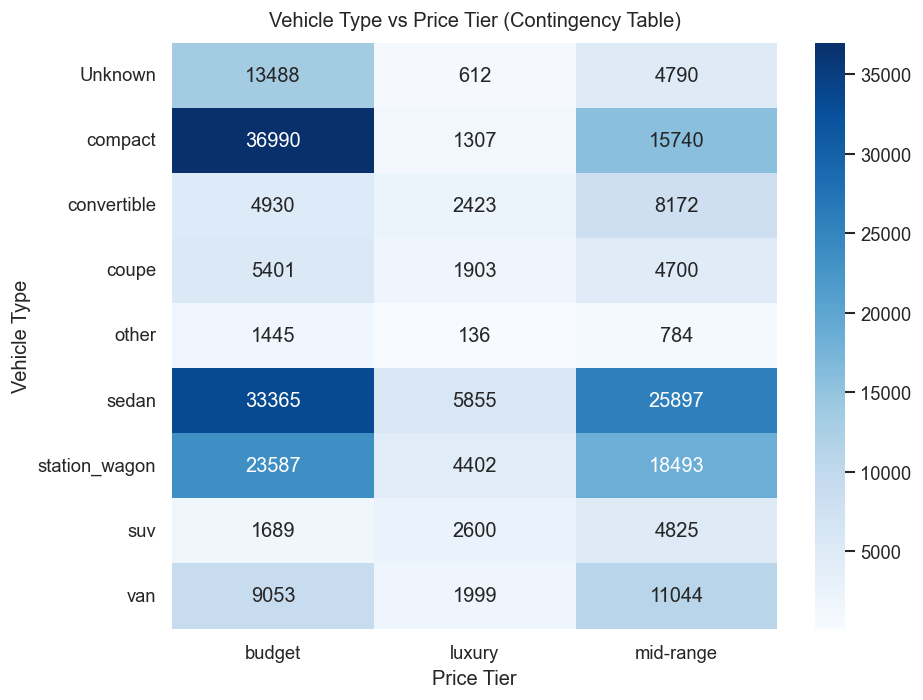

In [14]:
ct = pd.crosstab(df["vehicleType"], df["price_tier"])
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", ax=ax)
style_axis(
    ax,
    "Vehicle Type vs Price Tier (Contingency Table)",
    xlabel="Price Tier",
    ylabel="Vehicle Type",
)
plt.tight_layout()

## Multivariate Analysis

Focus on relationships across multiple numeric features and target tiers.


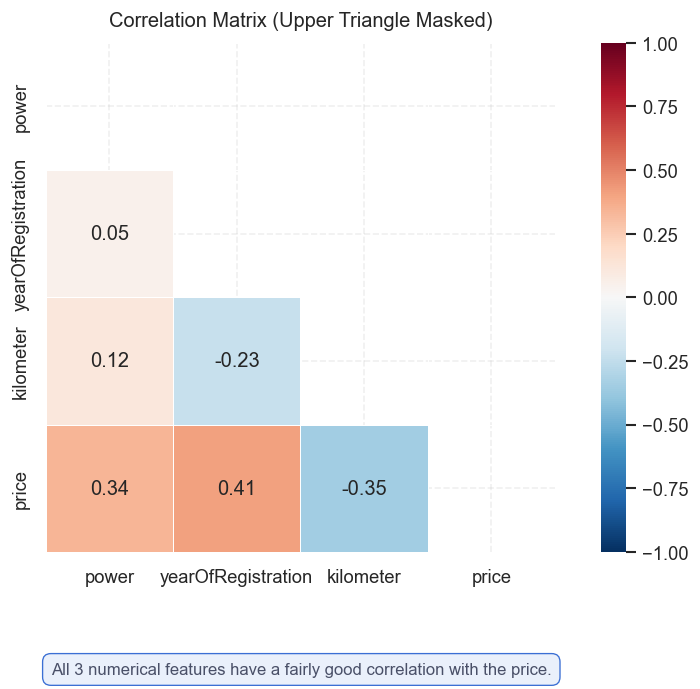

In [15]:
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=ax, vmin=-1, vmax=1, square=True, linewidths=0.5
)
style_axis(ax, "Correlation Matrix (Upper Triangle Masked)")
insight_box(
    ax,
    "All 3 numerical features have a fairly good correlation with the price.",
    "#EAF0FB",
    ACCENT_BLUE,
)
plt.tight_layout()

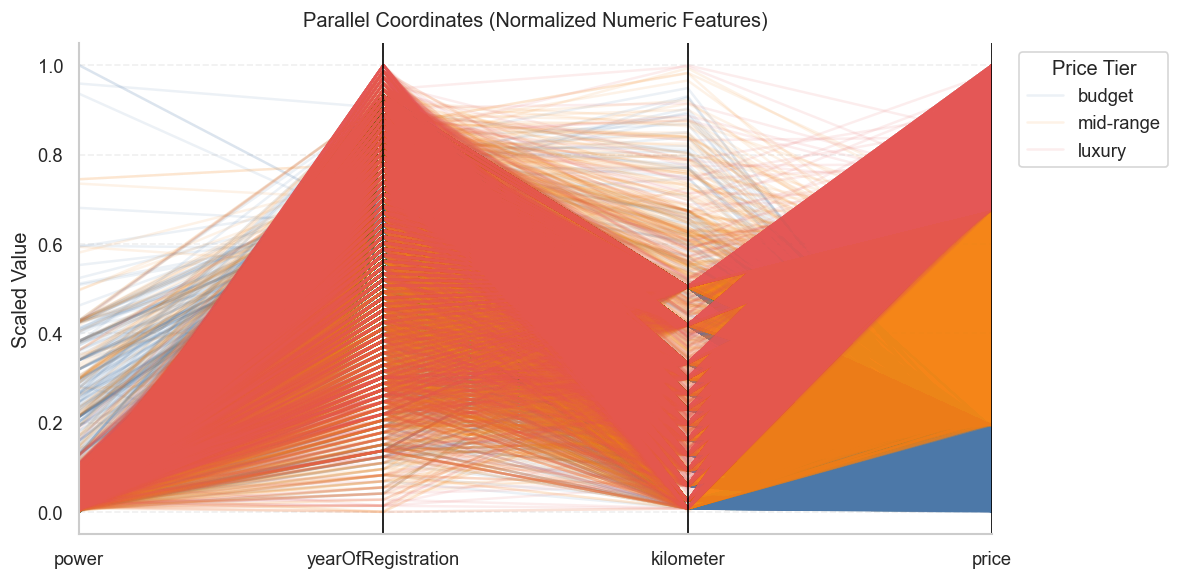

In [16]:
df_par = df[numeric_cols + ["price_tier"]].dropna()

tier_order = ["budget", "mid-range", "luxury", "Unknown"]
present_tiers = [t for t in tier_order if t in df_par["price_tier"].unique()]
present_tiers += [t for t in df_par["price_tier"].unique() if t not in tier_order]

df_par["price_tier"] = pd.Categorical(
    df_par["price_tier"], categories=present_tiers, ordered=True
)
df_par = df_par.sort_values("price_tier")

df_norm = df_par.copy()
for col in numeric_cols:
    min_val = df_norm[col].min()
    max_val = df_norm[col].max()
    df_norm[col] = (df_norm[col] - min_val) / (max_val - min_val)

colors = [palette.get(t, "#999999") for t in present_tiers]
fig, ax = plt.subplots(figsize=(10, 5))
parallel_coordinates(df_norm, "price_tier", color=colors, ax=ax, alpha=0.1)
style_axis(ax, "Parallel Coordinates (Normalized Numeric Features)", ylabel="Scaled Value")
plt.legend(title="Price Tier", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

## Dashboard

A compact summary view inspired by the course dashboard layout (KPI cards + key charts).


/tmp/ipykernel_281765/3099831572.py:100: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  brand_tier = df.groupby(["brand", "price_tier"]).size().unstack(fill_value=0)


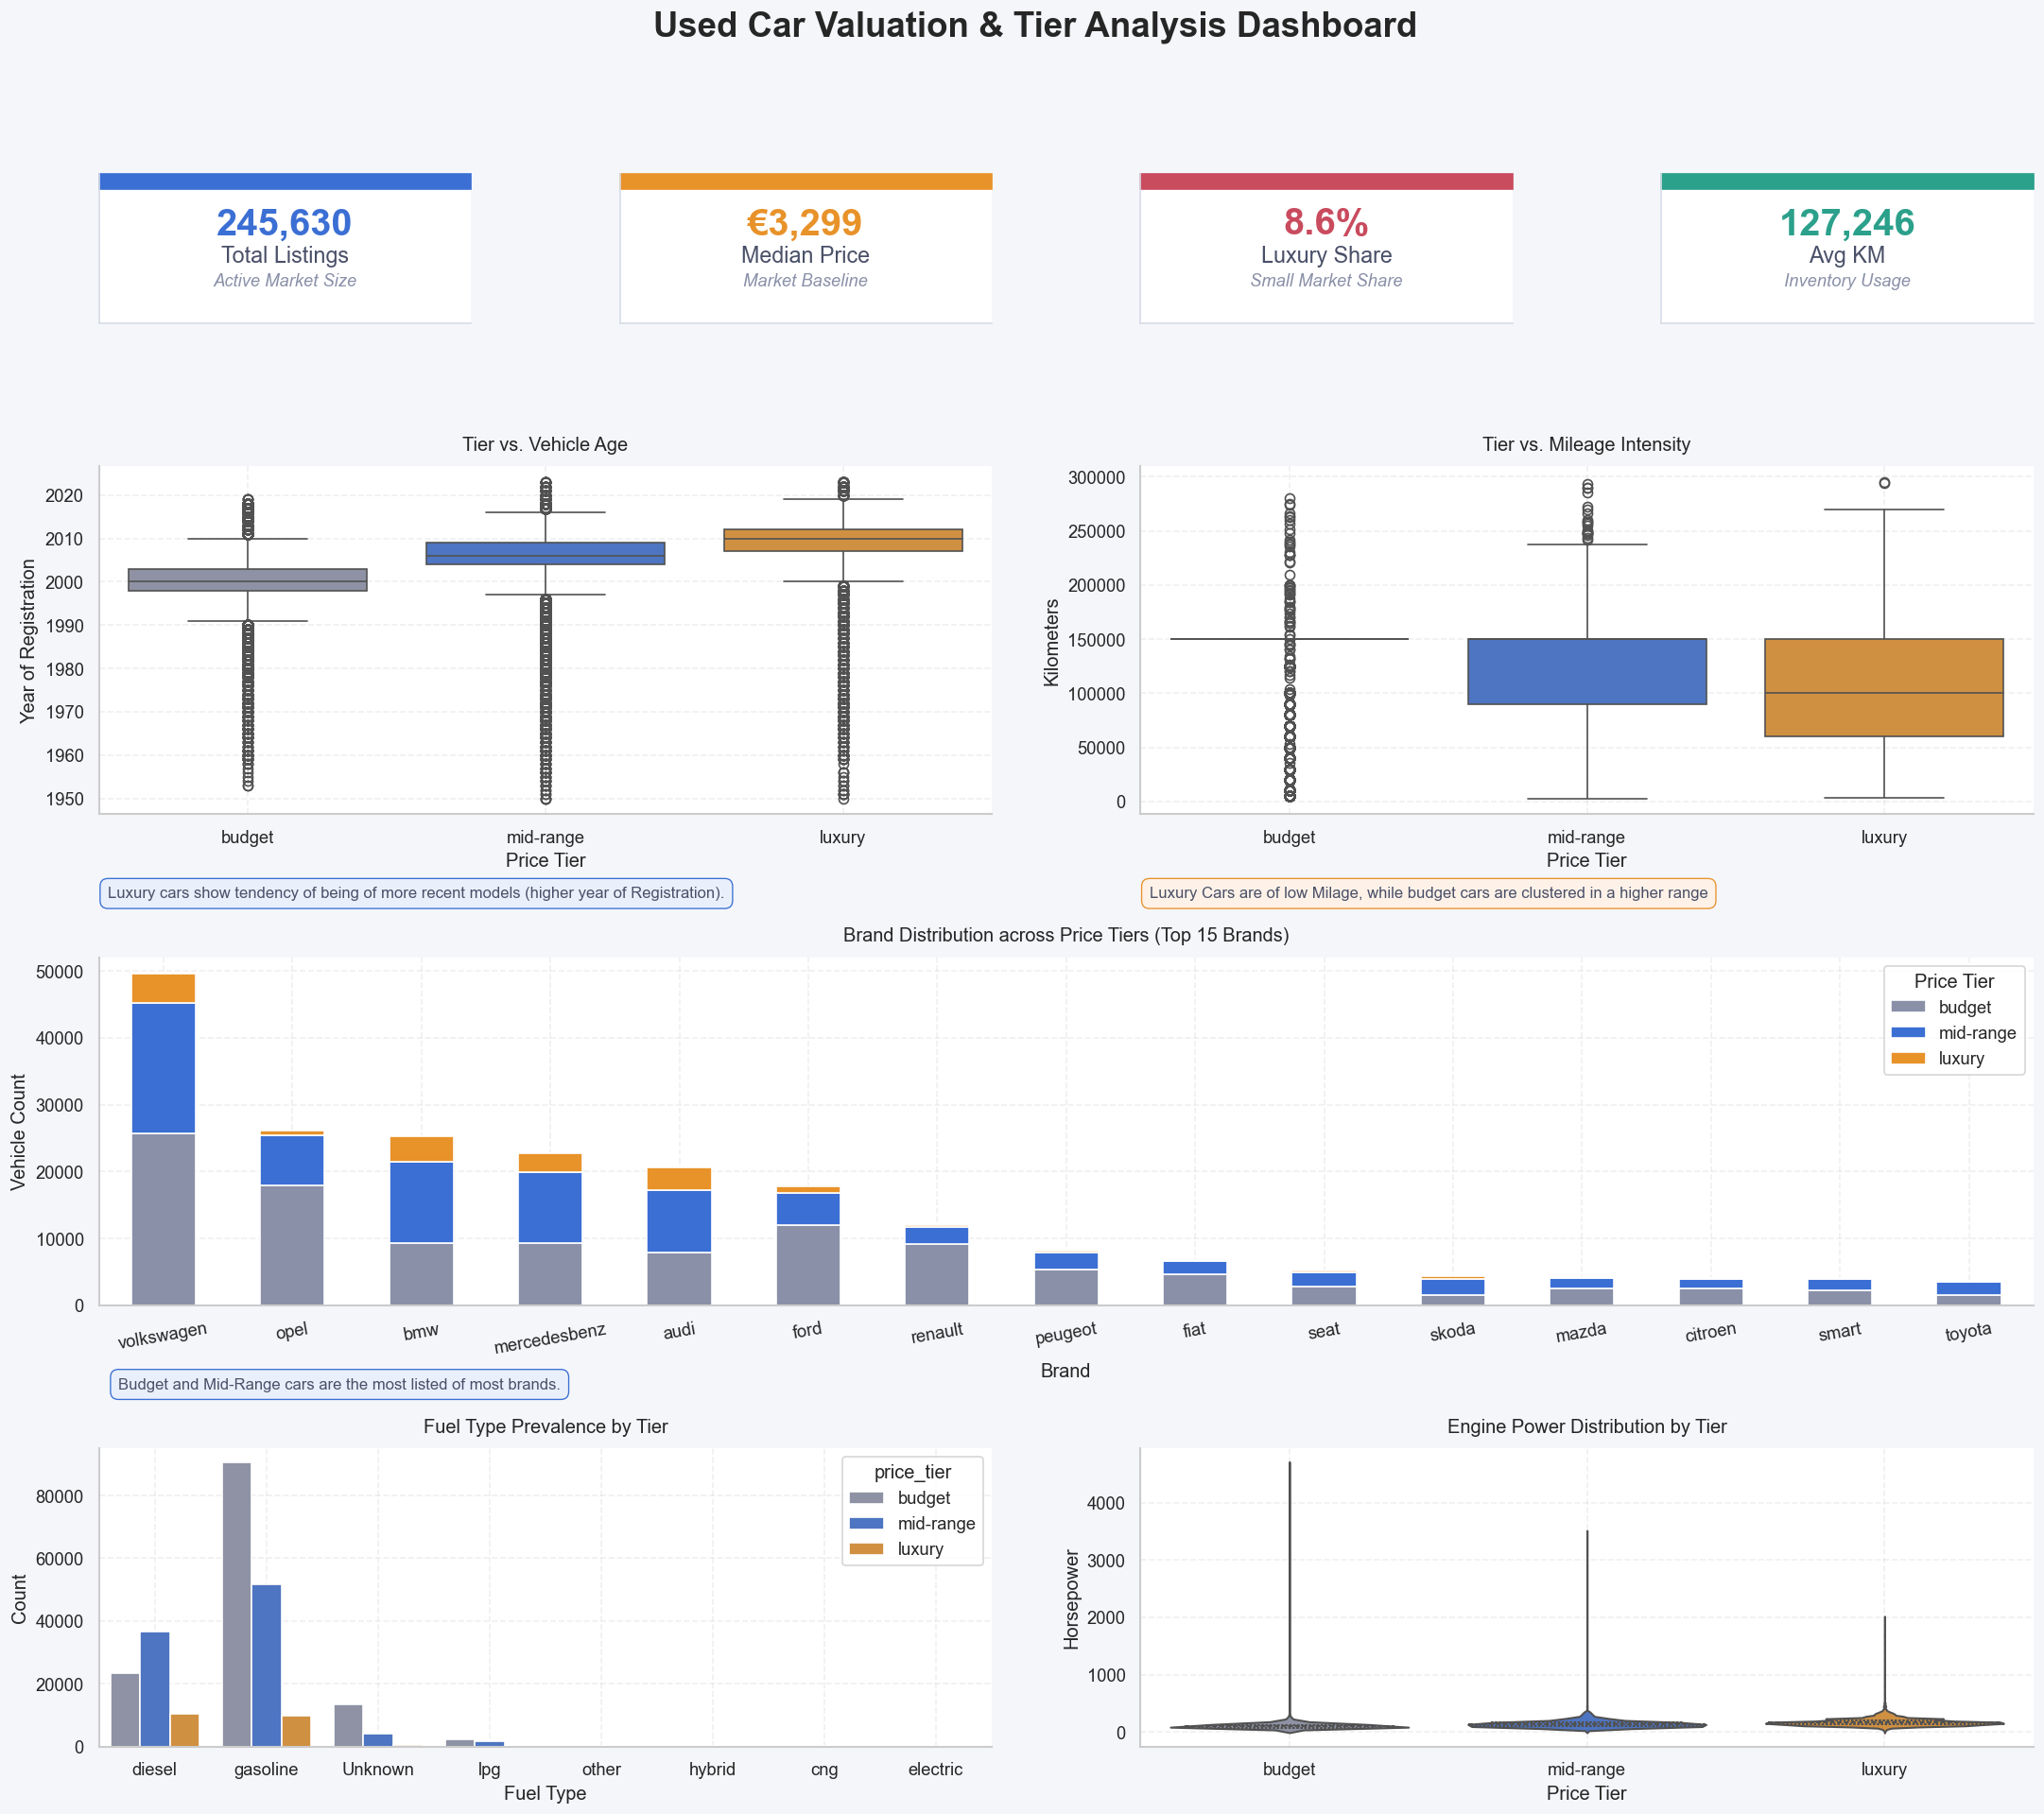

In [17]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Professional Color Palette
ACCENT_BLUE = "#3B6FD4"
ACCENT_GOLD = "#E8922A"  # Luxury
ACCENT_GREY = "#8A90A8"  # Budget
TEXT_DARK = "#1A1D2E"

# Enforce consistent tier ordering and palette across dashboard plots
TIER_ORDER = ["budget", "mid-range", "luxury"]
TIER_PALETTE = {
    "budget": ACCENT_GREY,
    "mid-range": ACCENT_BLUE,
    "luxury": ACCENT_GOLD,
    "Unknown": "#B0B0B0",
}

df["price_tier"] = (
    df["price_tier"]
    .astype("string")
    .fillna("Unknown")
    .str.strip()
    .str.lower()
)
df.loc[~df["price_tier"].isin(TIER_ORDER), "price_tier"] = "Unknown"
df["price_tier"] = pd.Categorical(df["price_tier"], categories=TIER_ORDER, ordered=True)

fig = plt.figure(figsize=(22, 18))
fig.patch.set_facecolor("#F4F6FA")
gs = gridspec.GridSpec(4, 4, hspace=0.5, wspace=0.4, height_ratios=[0.6, 1.4, 1.4, 1.2])

# --- ROW 0: KPI CARDS ---
ax1 = fig.add_subplot(gs[0, 0])
kpi_card(ax1, f"{len(df):,}", "Total Listings", "Active Market Size", ACCENT_BLUE)

ax2 = fig.add_subplot(gs[0, 1])
kpi_card(ax2, f"€{df['price'].median():,.0f}", "Median Price", "Market Baseline", ACCENT_GOLD)

ax3 = fig.add_subplot(gs[0, 2])
kpi_card(
    ax3,
    f"{(df['price_tier'] == 'luxury').mean() * 100:.1f}%",
    "Luxury Share",
    "Small Market Share",
    "#C94B5E",
)

ax4 = fig.add_subplot(gs[0, 3])
kpi_card(ax4, f"{df['kilometer'].mean():,.0f}", "Avg KM", "Inventory Usage", "#2BA08B")

# --- ROW 1: THE REASONING (Age & Mileage) ---
ax_age = fig.add_subplot(gs[1, 0:2])
sns.boxplot(
    x="price_tier",
    y="yearOfRegistration",
    data=df,
    order=TIER_ORDER,
    hue="price_tier",
    hue_order=TIER_ORDER,
    palette=TIER_PALETTE,
    dodge=False,
    ax=ax_age,
)
if ax_age.legend_:
    ax_age.legend_.remove()
style_axis(ax_age, "Tier vs. Vehicle Age", "Price Tier", "Year of Registration")
insight_box(
    ax_age,
    "Luxury cars show tendency of being of more recent models (higher year of Registration).",
    "#EAF0FB",
    ACCENT_BLUE,
)

ax_km = fig.add_subplot(gs[1, 2:4])
sns.boxplot(
    x="price_tier",
    y="kilometer",
    data=df,
    order=TIER_ORDER,
    hue="price_tier",
    hue_order=TIER_ORDER,
    palette=TIER_PALETTE,
    dodge=False,
    ax=ax_km,
)
if ax_km.legend_:
    ax_km.legend_.remove()
style_axis(ax_km, "Tier vs. Mileage Intensity", "Price Tier", "Kilometers")
insight_box(
    ax_km,
    "Luxury Cars are of low Milage, while budget cars are clustered in a higher range",
    "#FEF2E8",
    ACCENT_GOLD,
)

# --- ROW 2: MARKET COMPOSITION (Brand & Type) ---
ax_brand = fig.add_subplot(gs[2, :])
brand_tier = df.groupby(["brand", "price_tier"]).size().unstack(fill_value=0)
brand_tier = brand_tier.reindex(columns=TIER_ORDER, fill_value=0)

top_brands = brand_tier.sum(axis=1).sort_values(ascending=False).head(15).index
brand_tier.loc[top_brands].plot(
    kind="bar",
    stacked=True,
    ax=ax_brand,
    color=[TIER_PALETTE[t] for t in TIER_ORDER],
    rot=10
)
style_axis(ax_brand, "Brand Distribution across Price Tiers (Top 15 Brands)", "Brand", "Vehicle Count")
ax_brand.legend(title="Price Tier")
insight_box(
    ax_brand,
    "Budget and Mid-Range cars are the most listed of most brands.",
    "#EAF0FB",
    ACCENT_BLUE,
)

# --- ROW 3: TECHNICAL DRIVERS (Fuel & Power) ---
ax_fuel = fig.add_subplot(gs[3, 0:2])
sns.countplot(
    x="fuelType",
    hue="price_tier",
    hue_order=TIER_ORDER,
    data=df,
    palette=TIER_PALETTE,
    ax=ax_fuel,
)
style_axis(ax_fuel, "Fuel Type Prevalence by Tier", "Fuel Type", "Count")

ax_power = fig.add_subplot(gs[3, 2:4])
sns.violinplot(
    x="price_tier",
    y="power",
    data=df,
    order=TIER_ORDER,
    hue="price_tier",
    hue_order=TIER_ORDER,
    palette=TIER_PALETTE,
    dodge=False,
    ax=ax_power,
    inner="quart",
)
if ax_power.legend_:
    ax_power.legend_.remove()
style_axis(ax_power, "Engine Power Distribution by Tier", "Price Tier", "Horsepower")

plt.suptitle("Used Car Valuation & Tier Analysis Dashboard", fontsize=22, fontweight="bold", y=0.96)
plt.show()